# Employee Attrition Prediction System (ERP Analytics)

## Objective
To analyze employee data and build a machine learning model that predicts employee attrition and provides actionable insights through dashboards.

## Business Problem
High employee attrition leads to increased hiring costs, loss of talent, and productivity issues. This project aims to identify key factors influencing attrition.

## Team Contribution
- Data Cleaning & File work: Mahima Rana (0829IT221037)
- Model Building, EDA and deployment: Mayank Joshi (0829IT221038)
- Dashboard & Insights: Sachin Prajapat (0829IT221056)


##### Import Required Libraries

In [150]:
import pandas as pd # Data Manipulation
import numpy as np

import matplotlib.pyplot as plt # Data Visualization
import seaborn as sns
sns.set(style="whitegrid")

from sklearn.model_selection import (    # Model Selection & Evaluation
    train_test_split,
    learning_curve,
    RandomizedSearchCV
)

from sklearn.metrics import (
    accuracy_score,
    roc_auc_score,
    recall_score,
    confusion_matrix
)

from sklearn.linear_model import LogisticRegression     # Machine Learning Models
from sklearn.svm import SVC
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import RandomForestClassifier

from sklearn.preprocessing import (         # Preprocessing & Encoding
    LabelEncoder,
    OrdinalEncoder,
    OneHotEncoder,
    StandardScaler
) 

from sklearn.pipeline import Pipeline         # Pipelines & Transformers
from sklearn.compose import ColumnTransformer

from sklearn._config import set_config     # Scikit-learn Configuration
set_config(display='diagram')


##### Load Dataset

In [151]:
try:
    df = pd.read_csv('hr_manages.csv')
except Exception as e :
    print(f"Data can't be loaded. error :{e}")

Dataset Description
- Rows: 1470
- Columns: 33
- Target Variable: Attrition

##### Initial data Exploration

In [152]:
df.head(2)

,Unnamed: 0,age,attrition,businesstravel,dailyrate,department,distancefromhome,education,educationfield,employeenumber,environmentsatisfaction,gender,hourlyrate,jobinvolvement,joblevel,jobrole,jobsatisfaction,maritalstatus,monthlyincome,monthlyrate,numcompaniesworked,overtime,percentsalaryhike,performancerating,relationshipsatisfaction,stockoptionlevel,totalworkingyears,trainingtimeslastyear,worklifebalance,yearsatcompany,yearsincurrentrole,yearssincelastpromotion,yearswithcurrmanager
0,0,41,Yes,Travel_Rarely,1102,Sales,1,2,Life Sciences,1,2,Female,94,3,2,Sales Executive,4,Single,5993,19479,8,Yes,11,3,1,0,8,0,1,6,4,0,5
1,1,49,No,Travel_Frequently,279,Research & Development,8,1,Life Sciences,2,3,Male,61,2,2,Research Scientist,2,Married,5130,24907,1,No,23,4,4,1,10,3,3,10,7,1,7


In [153]:
df.describe()

,Unnamed: 0,age,dailyrate,distancefromhome,education,employeenumber,environmentsatisfaction,hourlyrate,jobinvolvement,joblevel,jobsatisfaction,monthlyincome,monthlyrate,numcompaniesworked,percentsalaryhike,performancerating,relationshipsatisfaction,stockoptionlevel,totalworkingyears,trainingtimeslastyear,worklifebalance,yearsatcompany,yearsincurrentrole,yearssincelastpromotion,yearswithcurrmanager
count,1470.000000,1470.000000,1470.000000,1470.000000,1470.000000,1470.000000,1470.000000,1470.000000,1470.000000,1470.000000,1470.000000,1470.000000,1470.000000,1470.000000,1470.000000,1470.000000,1470.000000,1470.000000,1470.000000,1470.000000,1470.000000,1470.000000,1470.000000,1470.000000,1470.000000
mean,734.500000,36.923810,802.485714,9.192517,2.912925,1024.865306,2.721769,65.891156,2.729932,2.063946,2.728571,6502.931293,14313.103401,2.693197,15.209524,3.153741,2.712245,0.793878,11.279592,2.799320,2.761224,7.008163,4.229252,2.187755,4.123129
std,424.496761,9.135373,403.509100,8.106864,1.024165,602.024335,1.093082,20.329428,0.711561,1.106940,1.102846,4707.956783,7117.786044,2.498009,3.659938,0.360824,1.081209,0.852077,7.780782,1.289271,0.706476,6.126525,3.623137,3.222430,3.568136
min,0.000000,18.000000,102.000000,1.000000,1.000000,1.000000,1.000000,30.000000,1.000000,1.000000,1.000000,1009.000000,2094.000000,0.000000,11.000000,3.000000,1.000000,0.000000,0.000000,0.000000,1.000000,0.000000,0.000000,0.000000,0.000000
25%,367.250000,30.000000,465.000000,2.000000,2.000000,491.250000,2.000000,48.000000,2.000000,1.000000,2.000000,2911.000000,8047.000000,1.000000,12.000000,3.000000,2.000000,0.000000,6.000000,2.000000,2.000000,3.000000,2.000000,0.000000,2.000000
50%,734.500000,36.000000,802.000000,7.000000,3.000000,1020.500000,3.000000,66.000000,3.000000,2.000000,3.000000,4919.000000,14235.500000,2.000000,14.000000,3.000000,3.000000,1.000000,10.000000,3.000000,3.000000,5.000000,3.000000,1.000000,3.000000
75%,1101.750000,43.000000,1157.000000,14.000000,4.000000,1555.750000,4.000000,83.750000,3.000000,3.000000,4.000000,8379.000000,20461.500000,4.000000,18.000000,3.000000,4.000000,1.000000,15.000000,3.000000,3.000000,9.000000,7.000000,3.000000,7.000000
max,1469.000000,60.000000,1499.000000,29.000000,5.000000,2068.000000,4.000000,100.000000,4.000000,5.000000,4.000000,19999.000000,26999.000000,9.000000,25.000000,4.000000,4.000000,3.000000,40.000000,6.000000,4.000000,40.000000,18.000000,15.000000,17.000000


In [154]:
df.shape

(1470, 33)

In [155]:
df.duplicated().sum()

np.int64(0)

In [156]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1470 entries, 0 to 1469
Data columns (total 33 columns):
 #   Column                    Non-Null Count  Dtype 
---  ------                    --------------  ----- 
 0   Unnamed: 0                1470 non-null   int64 
 1   age                       1470 non-null   int64 
 2   attrition                 1470 non-null   object
 3   businesstravel            1470 non-null   object
 4   dailyrate                 1470 non-null   int64 
 5   department                1470 non-null   object
 6   distancefromhome          1470 non-null   int64 
 7   education                 1470 non-null   int64 
 8   educationfield            1470 non-null   object
 9   employeenumber            1470 non-null   int64 
 10  environmentsatisfaction   1470 non-null   int64 
 11  gender                    1470 non-null   object
 12  hourlyrate                1470 non-null   int64 
 13  jobinvolvement            1470 non-null   int64 
 14  joblevel                

In [157]:
print(f"There are {df.isnull().sum().sum()} null values in the dataset.\nThere are {df.duplicated().sum()} duplicates in the dataset.")

There are 0 null values in the dataset.
There are 0 duplicates in the dataset.


##### Data cleaning and preprocessing

In [158]:
df.columns = df.columns.str.lower()

In [159]:
def Info():
    total_drops = 0
    for col in df.columns:
        if df[col].nunique() < 20:
            print(df[col].name)
            print(df[col].unique())
            if df[col].nunique() <= 1:
                total_drops += 1
                print(f"Removing {col} from the data frame.")
                df.drop(columns=col, inplace= True)

    print(f"total droped col = {total_drops}")
                

Info()

attrition
['Yes' 'No']
businesstravel
['Travel_Rarely' 'Travel_Frequently' 'Non-Travel']
department
['Sales' 'Research & Development' 'Human Resources']
education
[2 1 4 3 5]
educationfield
['Life Sciences' 'Other' 'Medical' 'Marketing' 'Technical Degree'
 'Human Resources']
environmentsatisfaction
[2 3 4 1]
gender
['Female' 'Male']
jobinvolvement
[3 2 4 1]
joblevel
[2 1 3 4 5]
jobrole
['Sales Executive' 'Research Scientist' 'Laboratory Technician'
 'Manufacturing Director' 'Healthcare Representative' 'Manager'
 'Sales Representative' 'Research Director' 'Human Resources']
jobsatisfaction
[4 2 3 1]
maritalstatus
['Single' 'Married' 'Divorced']
numcompaniesworked
[8 1 6 9 0 4 5 2 7 3]
overtime
['Yes' 'No']
percentsalaryhike
[11 23 15 12 13 20 22 21 17 14 16 18 19 24 25]
performancerating
[3 4]
relationshipsatisfaction
[1 4 2 3]
stockoptionlevel
[0 1 3 2]
trainingtimeslastyear
[0 3 2 5 1 4 6]
worklifebalance
[1 3 2 4]
yearsincurrentrole
[ 4  7  0  2  5  9  8  3  6 13  1 15 14 16 11 10 12

In [160]:
df.sample()

,unnamed: 0,age,attrition,businesstravel,dailyrate,department,distancefromhome,education,educationfield,employeenumber,environmentsatisfaction,gender,hourlyrate,jobinvolvement,joblevel,jobrole,jobsatisfaction,maritalstatus,monthlyincome,monthlyrate,numcompaniesworked,overtime,percentsalaryhike,performancerating,relationshipsatisfaction,stockoptionlevel,totalworkingyears,trainingtimeslastyear,worklifebalance,yearsatcompany,yearsincurrentrole,yearssincelastpromotion,yearswithcurrmanager
836,836,29,Yes,Travel_Rarely,408,Sales,23,1,Life Sciences,1165,4,Female,45,2,3,Sales Executive,1,Married,7336,11162,1,No,13,3,1,1,11,3,1,11,8,3,10


In [161]:
col_drop = ['employeenumber', "unnamed: 0" ] 
df = df.drop(columns= col_drop , axis= 1)

In [162]:
df.to_csv("hr_manages.csv", index= True)

In [163]:
df.sample(1)

,age,attrition,businesstravel,dailyrate,department,distancefromhome,education,educationfield,environmentsatisfaction,gender,hourlyrate,jobinvolvement,joblevel,jobrole,jobsatisfaction,maritalstatus,monthlyincome,monthlyrate,numcompaniesworked,overtime,percentsalaryhike,performancerating,relationshipsatisfaction,stockoptionlevel,totalworkingyears,trainingtimeslastyear,worklifebalance,yearsatcompany,yearsincurrentrole,yearssincelastpromotion,yearswithcurrmanager
577,37,No,Travel_Rarely,571,Research & Development,10,1,Life Sciences,4,Female,82,3,1,Research Scientist,1,Divorced,2782,19905,0,Yes,13,3,2,2,6,3,2,5,3,4,3


##### Exploratory Data Analysis (EDA)

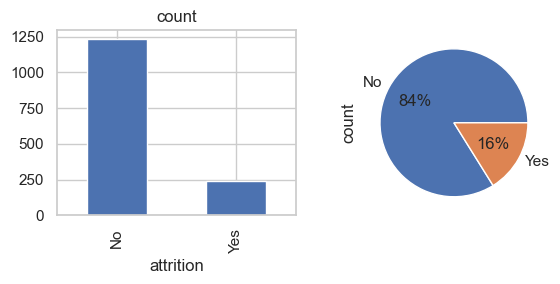

In [164]:
fig  , ax = plt.subplots(1,2, figsize=(6,3) )
df["attrition"].value_counts().plot(kind= "bar",subplots= True,  ax = ax[0])
df["attrition"].value_counts().plot(kind= "pie" , autopct = "%1.0f%%"  , subplots= True , ax = ax[1])
plt.tight_layout()
plt.show()

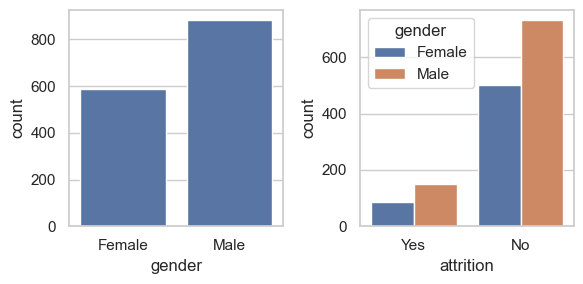

In [165]:
x = df.groupby("gender")["attrition"].value_counts()
fig , ax = plt.subplots(1,2 , figsize= (6,3))
sns.countplot(x = df.gender , ax = ax[0])
sns.countplot(x = df.attrition , hue = df.gender , data = df , ax = ax[1])
plt.tight_layout()
plt.show()

Higher male attrition is observed in absolute numbers, largely due to higher male representation in the workforce rather than gender-driven resignation behavior.

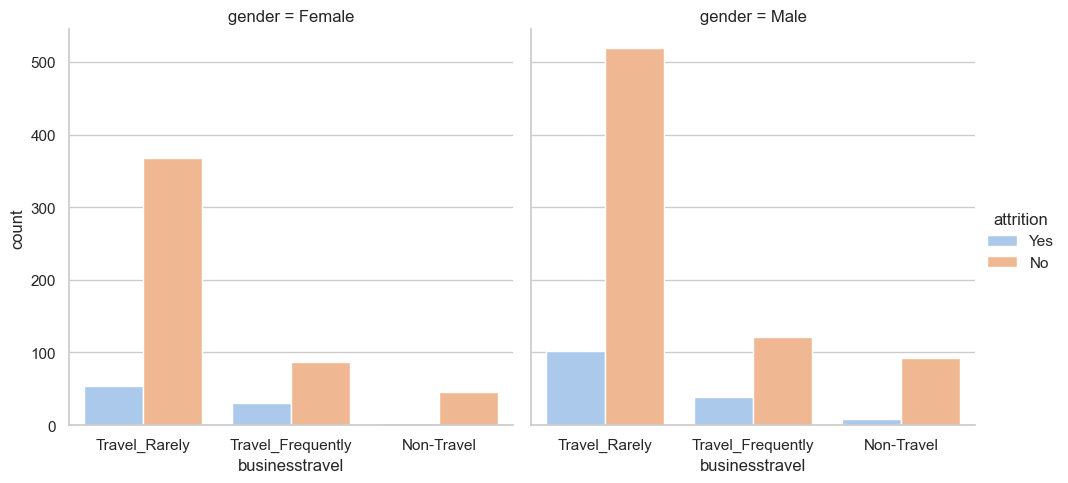

In [166]:
df.groupby(["gender", "attrition"])['businesstravel'].value_counts()
sns.catplot(x=df.businesstravel, hue=df.attrition, col=df.gender, data=df, kind='count', palette='pastel')
plt.show()

Business travel has very noticeable afacts on the attration but females have higher rate of attration if the job role is travel relatetd.


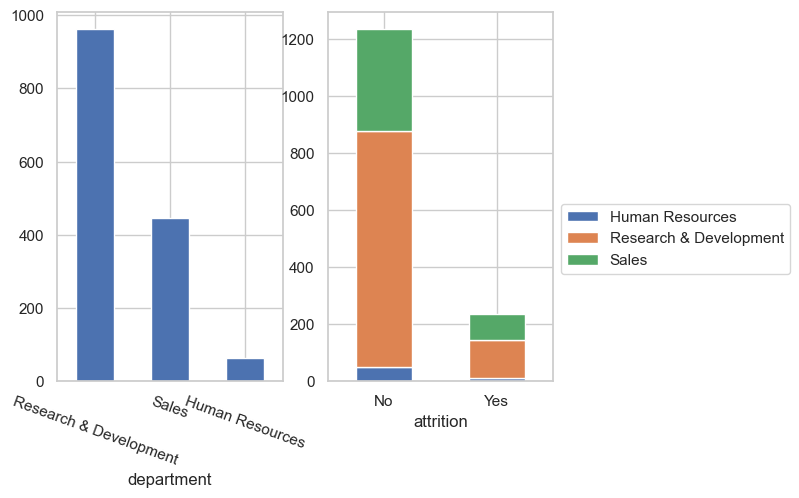

In [167]:
fig , ax = plt.subplots(1,2 , figure = (6, 12))
df["department"].value_counts().plot(kind = "bar" , ax = ax[0])
ax[0].tick_params(axis='x', rotation=340)
df.groupby("attrition")["department"].value_counts().unstack().plot(kind = "bar"  ,  stacked= True , ax = ax[1] )
ax[1].legend(
    loc='upper left',
    bbox_to_anchor=(1, 0.5)
)
ax[1].tick_params(axis='x', rotation=0)
#plt.tight_layout()
plt.show()

R&D and Sales show higher attrition in absolute numbers due to larger workforce size, while HR shows minimal attrition because of a smaller team.

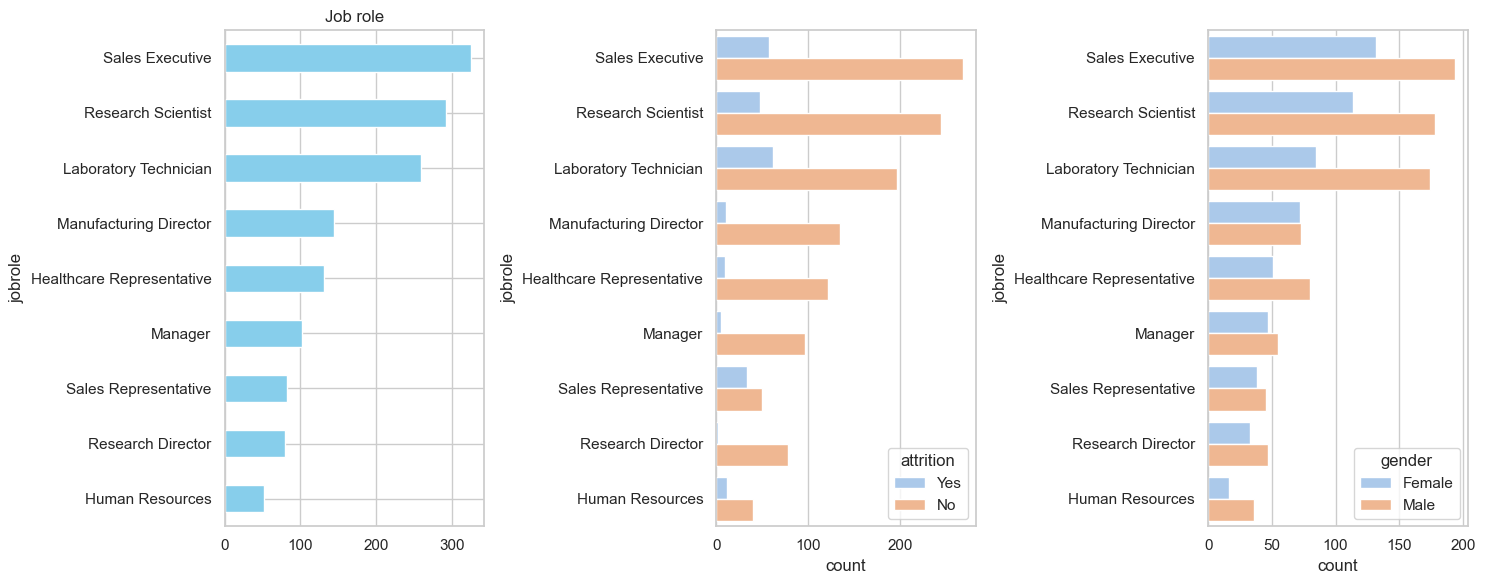

In [168]:
fig , ax = plt.subplots(1,3 , figsize= (15,6))
df["jobrole"].value_counts().sort_values(ascending=True).plot(kind = "barh" , title = "Job role" , color = "skyblue" , ax = ax[0])
sns.countplot(data = df , y  = df.jobrole , hue = df.attrition , palette= "pastel" , ax = ax[1])
sns.countplot(data = df , y = df.jobrole , hue = df.gender , palette= "pastel" , ax = ax[2])
plt.tight_layout()
plt.show()

Sales and technical roles experience higher attrition, while senior and managerial roles show greater retention due to stability and growth opportunities.

##### Feature Selection

In [169]:
x = df.drop(columns= "attrition" , axis= 1) #droping the target from the orignal dataframe to use it as input data
y = df.attrition

##### Encoding and Scaling features

In [170]:
y = df['attrition'].map({'No': 0, 'Yes': 1})
col_obj_ord = ['businesstravel' , 'educationfield' , 'jobrole' , 'maritalstatus']
col_obj_onehot = ['department' ,'gender' ,'overtime']
num_col_countinus = ["age","dailyrate","distancefromhome","hourlyrate","monthlyincome","monthlyrate",
                     "numcompaniesworked","percentsalaryhike","totalworkingyears","trainingtimeslastyear"
                     ,"yearsatcompany","yearsincurrentrole","yearssincelastpromotion","yearswithcurrmanager"]
num_col_oridinal =  ["education","environmentsatisfaction","jobinvolvement","joblevel","jobsatisfaction",
                     "performancerating","relationshipsatisfaction","stockoptionlevel","worklifebalance"]

preprocessor = ColumnTransformer(
    transformers=[
        ('cat_col_ord' , OrdinalEncoder(), col_obj_ord),
        ("cat_col_one" , OneHotEncoder(), col_obj_onehot),
        ("num_col_countinus" , StandardScaler() , num_col_countinus),
        ("num_col_oridinal" , "passthrough" , num_col_oridinal) 
    ]
)

##### train - test split

In [171]:
x_train , x_test , y_train , y_test = train_test_split(
    x,y , test_size = 0.2
    )

##### Pipeline

In [172]:

set_config(display='diagram')
clf = Pipeline(steps = [
    ('preprocessor' , preprocessor),
    ('classifier' , RandomForestClassifier())])
clf

,steps,"[('preprocessor', ...), ('classifier', ...)]"
,transform_input,None
,memory,None
,verbose,False
,transformers,"[('cat_col_ord', ...), ('cat_col_one', ...), ...]"
,remainder,'drop'
,sparse_threshold,0.3
,n_jobs,None
,transformer_weights,None
,verbose,False
,verbose_feature_names_out,True


##### Model Selection 

In [173]:
models = [
    {'model': LogisticRegression(max_iter=200, class_weight='balanced'), 'name': 'Logistic Regression'},
    {'model': SVC(class_weight='balanced', probability=True), 'name': 'Support Vector Machine'},
    {'model': DecisionTreeClassifier(class_weight='balanced'), 'name': 'Decision Tree'},
    {'model': RandomForestClassifier(class_weight='balanced'), 'name': 'Random Forest'}
]


from sklearn.metrics import recall_score

for m in models:
    clf = Pipeline(steps=[
        ('preprocessor', preprocessor),
        ('classifier', m['model'])
    ])
    
    clf.fit(x_train, y_train)
    y_pred = clf.predict(x_test)
    recall = recall_score(y_test, y_pred)
    
    print(f"Recall of the model {m['name']} is {recall*100:.2f}%")

Recall of the model Logistic Regression is 80.49%
Recall of the model Support Vector Machine is 75.61%
Recall of the model Decision Tree is 34.15%
Recall of the model Random Forest is 24.39%


##### Hyperprerameter tuning

In [174]:

param_grid = [ 
    {'classifier': [LogisticRegression(max_iter=100 , class_weight= "balanced")],
     'classifier__C': [0.1, 1.0, 10.0],
     'classifier__solver': ['liblinear', 'saga'],
     'classifier__penalty': ['l1', 'l2']},
     {'classifier': [SVC(class_weight="balanced")],
        'classifier__C': [0.1, 1.0, 10.0],
        'classifier__kernel': ['linear', 'rbf', 'poly'],
        'classifier__gamma': ['scale', 'auto']}
]
from sklearn.model_selection import StratifiedKFold

cv = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)

grid_search = RandomizedSearchCV(
    clf,
    param_grid,
    cv=cv,
    n_iter=10,
    n_jobs=-1,
    scoring='recall',
    verbose=2
)

best_model = grid_search.fit(x_train, y_train)

print("Best params:", best_model.best_params_)
print("Best score:", best_model.best_score_)


Fitting 5 folds for each of 10 candidates, totalling 50 fits
Best params: {'classifier__kernel': 'rbf', 'classifier__gamma': 'scale', 'classifier__C': 0.1, 'classifier': SVC(class_weight='balanced')}
Best score: 0.7502564102564102


In [175]:
clf = Pipeline(steps = [
    ('preprocessor' , preprocessor),
    ('classifier' , SVC(class_weight= "balanced" , kernel = 'poly' ,gamma= 'scale' ,C = 0.1))])

##### Model Evaluation

In [176]:
attrition_model =  clf.fit(x_train , y_train)
y_pred = attrition_model.predict(x_test)
per = recall_score(y_test , y_pred)
print(f"the recall of the model is {per*100:.2f}%")


the recall of the model is 78.05%



learning curve shows model performance vs. training set size.


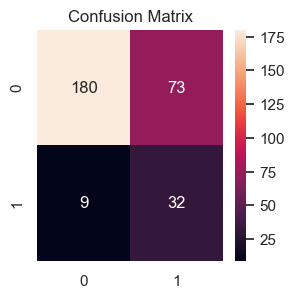

In [177]:
cm = confusion_matrix(y_test, y_pred)
plt.figure(figsize=(3,3))
sns.heatmap(cm, annot=True, fmt='d')
plt.title("Confusion Matrix")
plt.show()


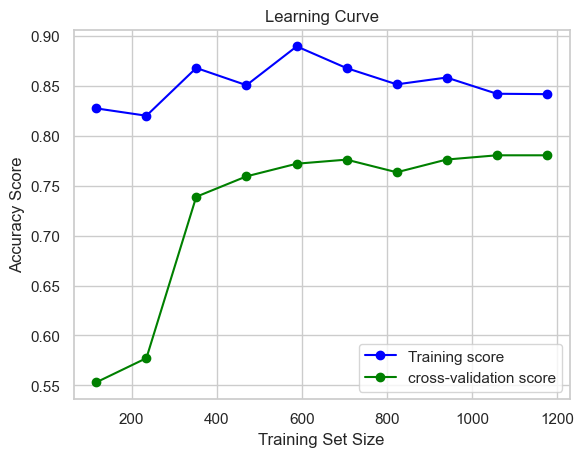

In [178]:

train_size , train_score , test_score = learning_curve(attrition_model , x , y , cv = 5 , n_jobs= -1 , scoring= 'recall' , train_sizes= np.linspace(0.1, 1.0, 10))
train_mean = np.mean(train_score , axis= 1)
test_mean = np.mean(test_score , axis = 1)

plt.plot(train_size ,train_mean , 'o-' , label = "Training score" , color = 'blue' )
plt.plot(train_size ,test_mean , 'o-' , label = "cross-validation score" , color = 'green' )
plt.xlabel("Training Set Size")
plt.ylabel("Accuracy Score")
plt.title("Learning Curve")
plt.legend(loc = 'best')
plt.show()

Key Insights
- Overtime is the strongest predictor of attrition
- Employees with low job satisfaction are 2x more likely to leave
- Random Forest outperformed Logistic Regression


##### Model Dumping for Deployment

In [189]:
attrition_model = Pipeline(steps=[
    ('preprocessor', preprocessor),
    ('classifier', LogisticRegression(
        max_iter=200,
        class_weight='balanced'
    ))
])

attrition_model.fit(x_train, y_train)

from joblib import dump
dump(attrition_model, "attrition_model.pkl")


['attrition_model.pkl']

In [190]:
print(attrition_model.named_steps['classifier'])


LogisticRegression(class_weight='balanced', max_iter=200)
